In [1]:
import sys
import pandas as pd
sys.path.append("../src")
from stat_tests import run_adf_tests_by_country
from figure_utils import (
    plot_load_distributions,
    plot_temp_vs_load,
    plot_hdd_cdd_relationships,
    plot_extreme_boxplots,
    plot_acf_pacf_by_country
)
from data_utils import split_data

In [2]:
df = pd.read_csv("../data/processed_data.csv", index_col=0, parse_dates=True)
df = df.asfreq("D")
df = df.dropna()

In [3]:
train_start_year = 2010
forecast_year = 2025

val_year = forecast_year - 1
train_end_year = forecast_year - 2

train_data, val_data, development_data, forecast_data = split_data(
    df,
    train_start_year=train_start_year,
    forecast_year=forecast_year
)

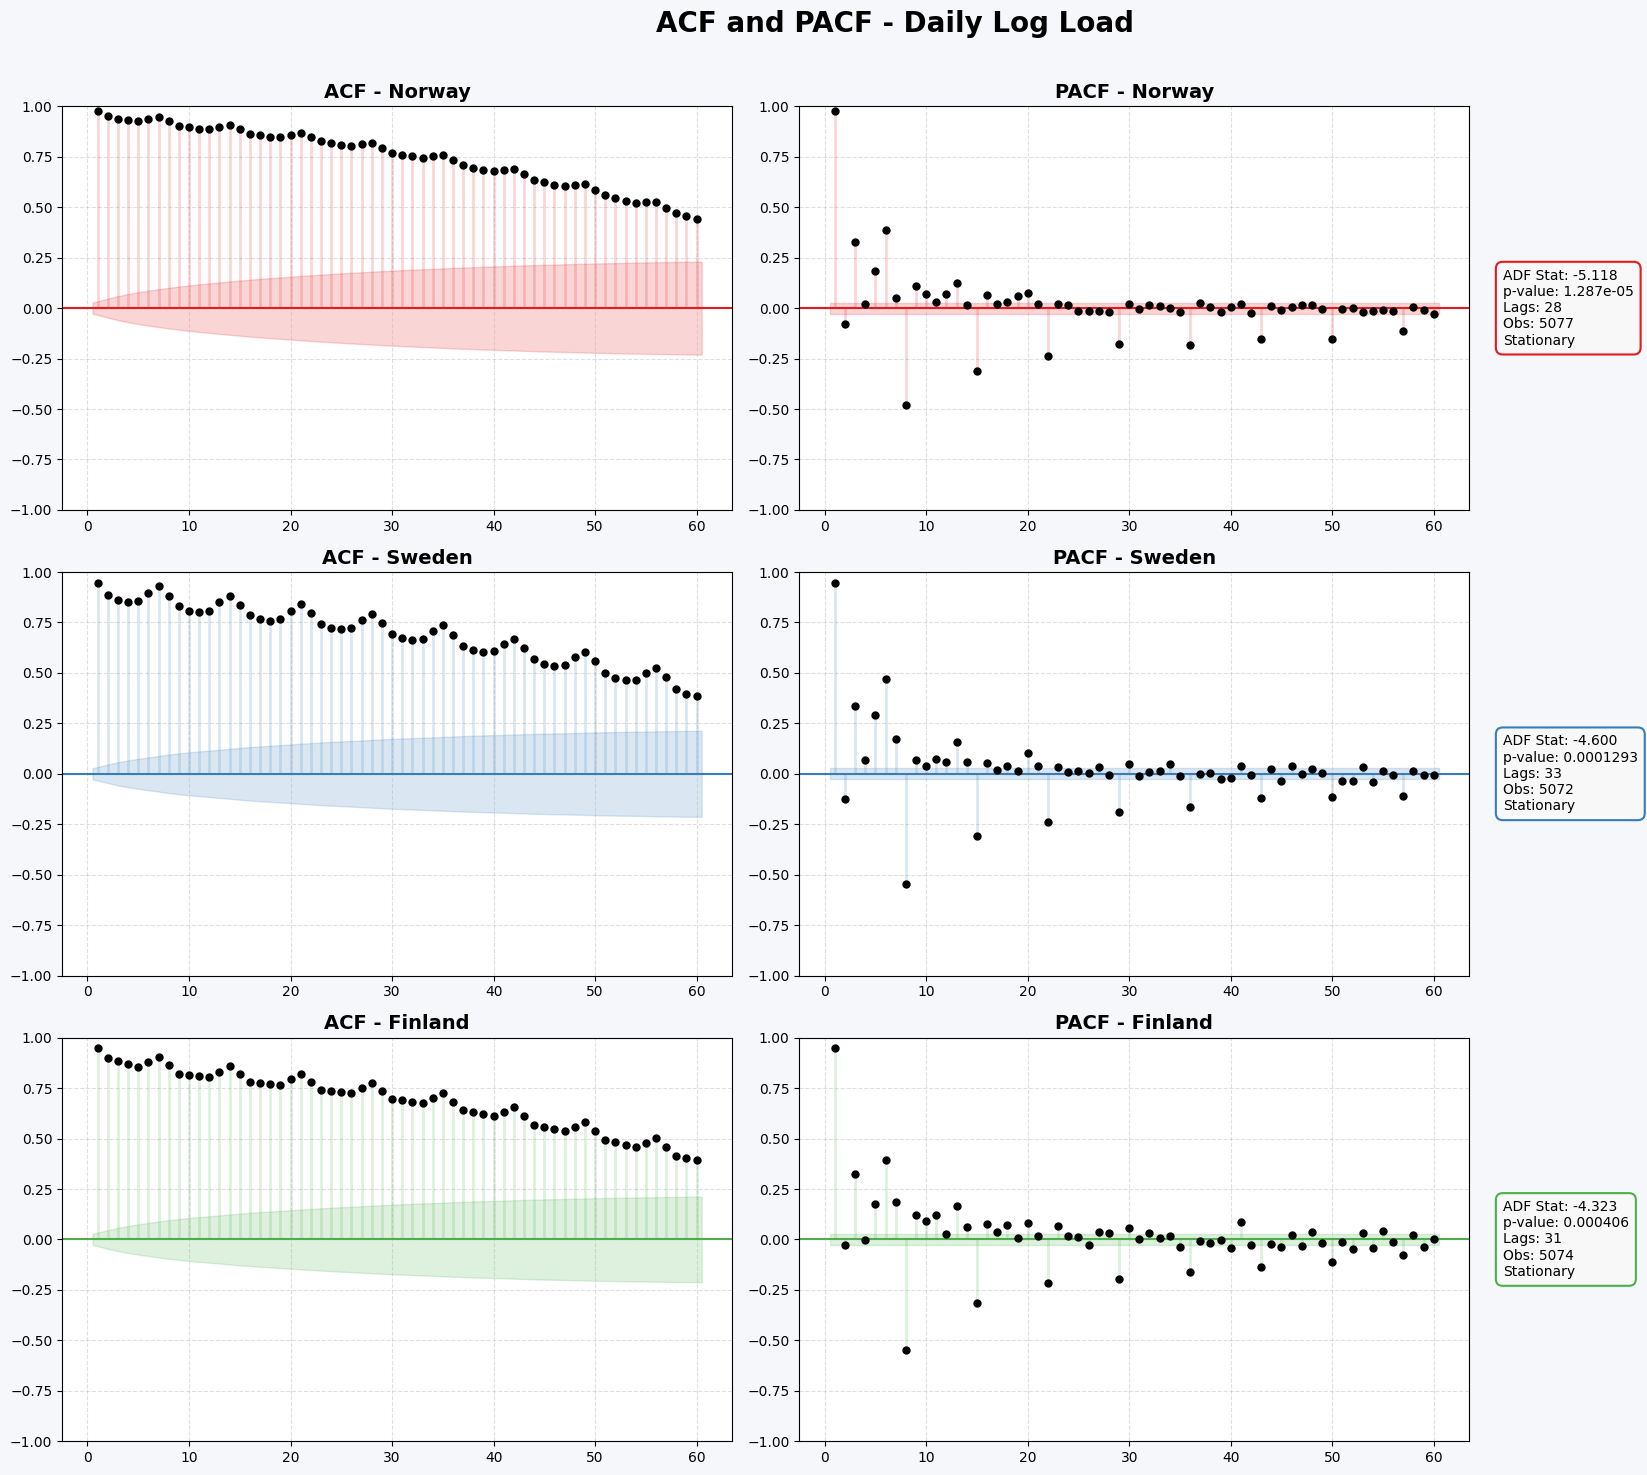

,Country,ADF Statistic,p-value,Used lags,Observations,Conclusion
0,Norway,-5.118425,0.000013,28,5077,Stationary
1,Sweden,-4.599756,0.000129,33,5072,Stationary
2,Finland,-4.322514,0.000406,31,5074,Stationary


In [4]:
# Level log load
adf_level = plot_acf_pacf_by_country(
    data=train_data,
    transform="level",
    lags=60
)

adf_level

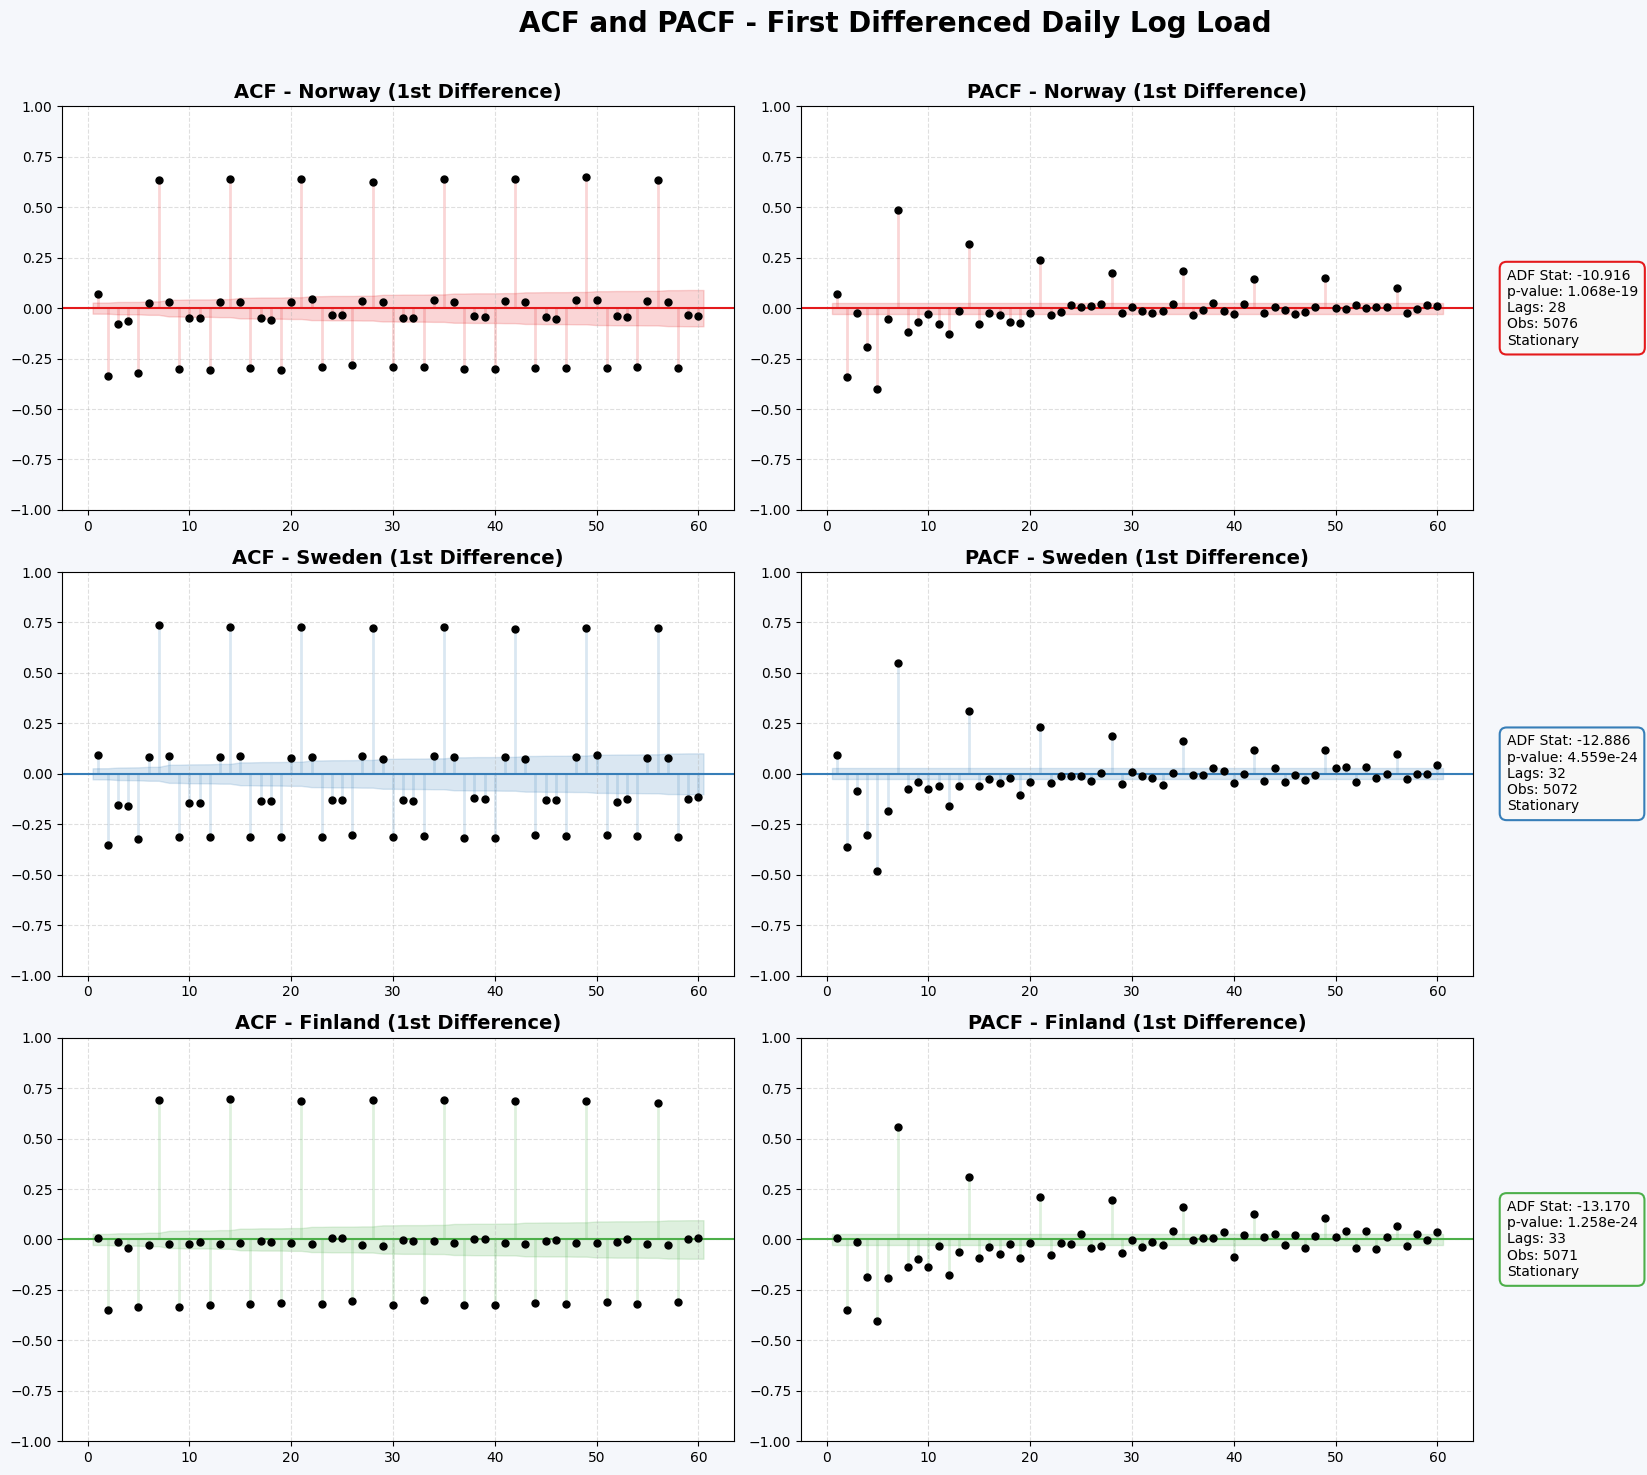

,Country,ADF Statistic,p-value,Used lags,Observations,Conclusion
0,Norway,-10.915847,0.0,28,5076,Stationary
1,Sweden,-12.885713,0.0,32,5072,Stationary
2,Finland,-13.169656,0.0,33,5071,Stationary


In [5]:
# First difference log load
adf_first_diff = plot_acf_pacf_by_country(
    data=train_data,
    transform="first_difference",
    lags=60
)

adf_first_diff

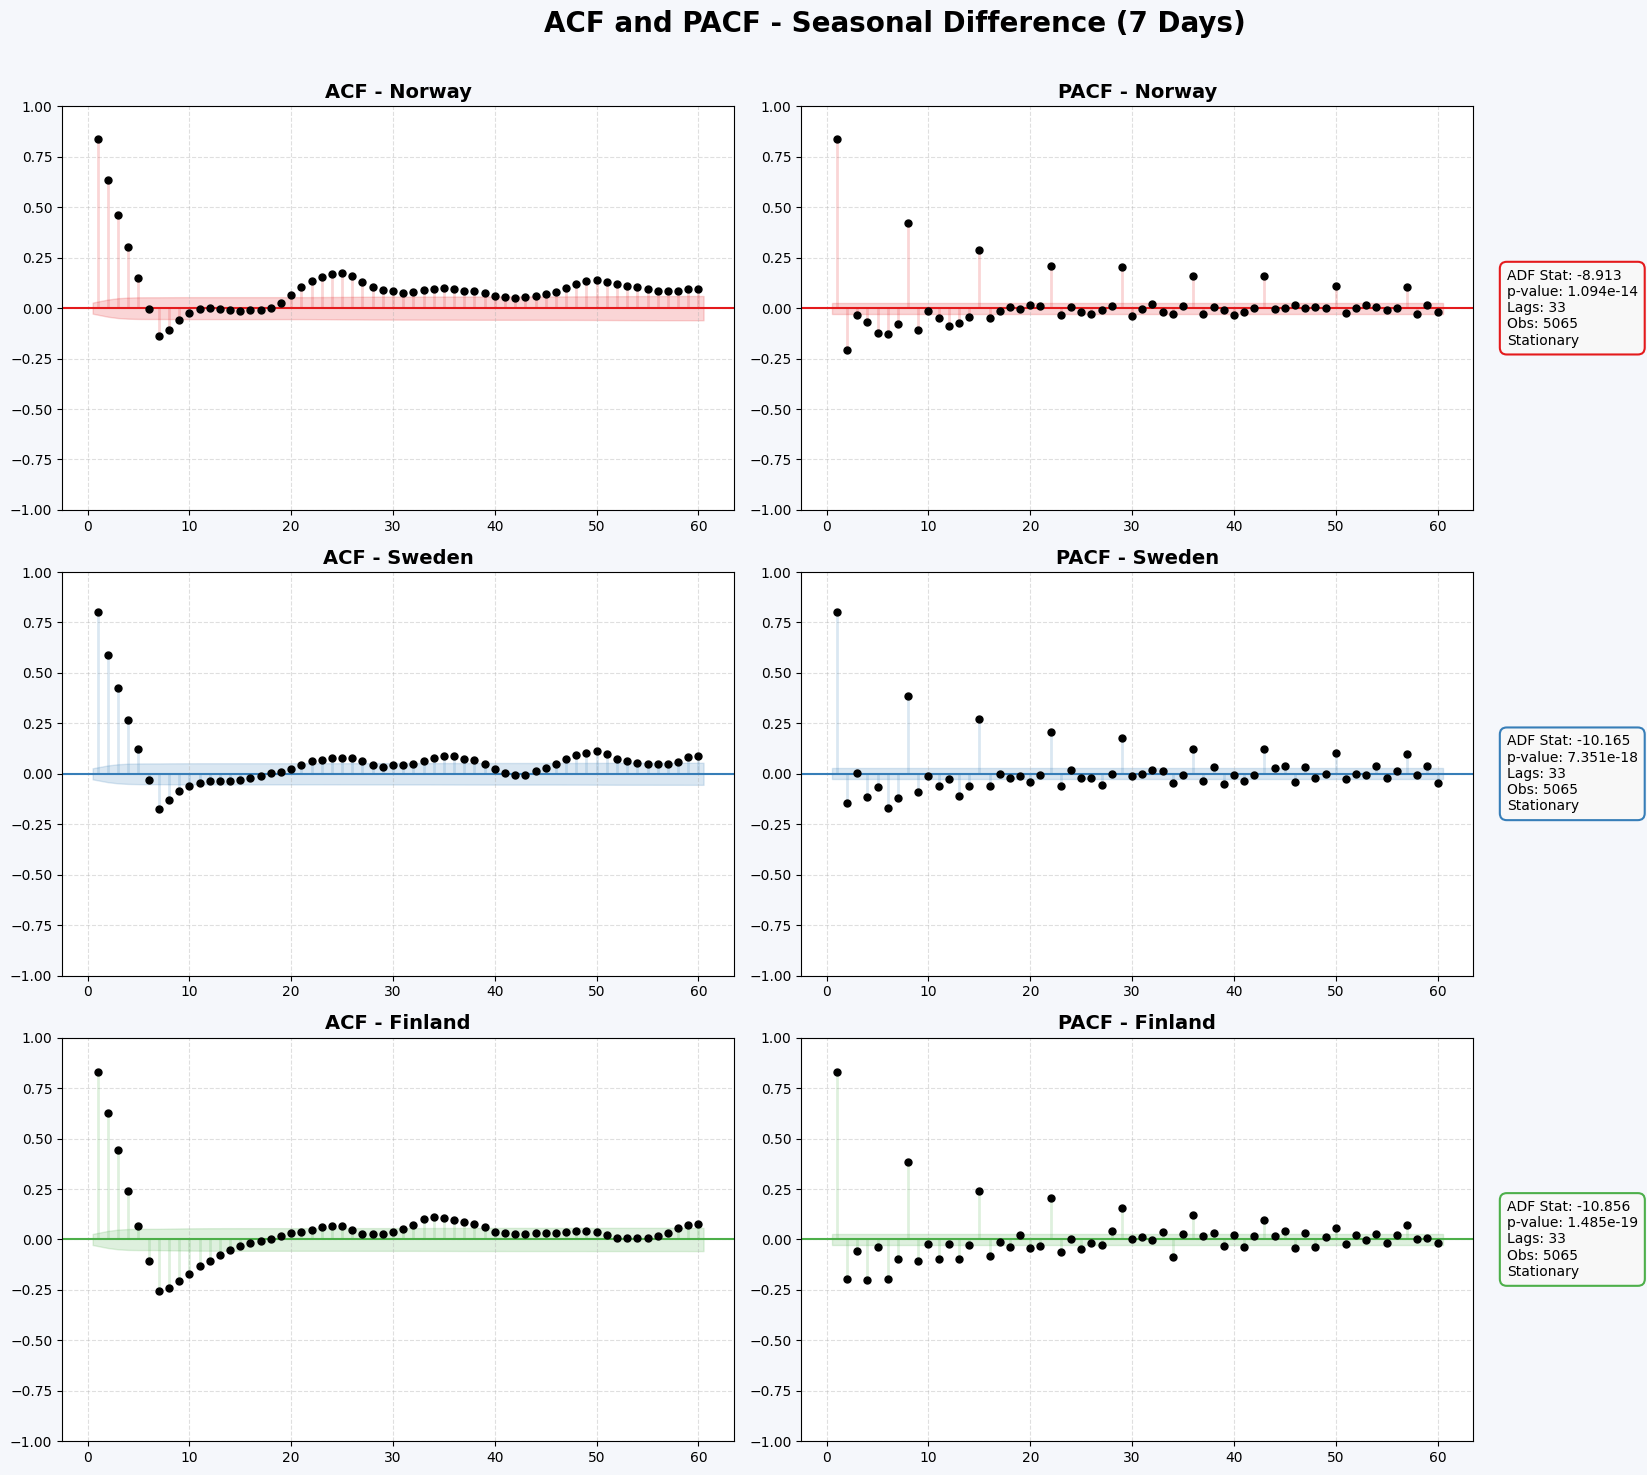

,Country,ADF Statistic,p-value,Used lags,Observations,Conclusion
0,Norway,-8.912629,0.0,33,5065,Stationary
1,Sweden,-10.164694,0.0,33,5065,Stationary
2,Finland,-10.856261,0.0,33,5065,Stationary


In [6]:
# Seasonal difference log load
adf_seasonal_diff = plot_acf_pacf_by_country(
    data=train_data,
    transform="seasonal_difference",
    seasonal_lag=7,
    lags=60
)

adf_seasonal_diff

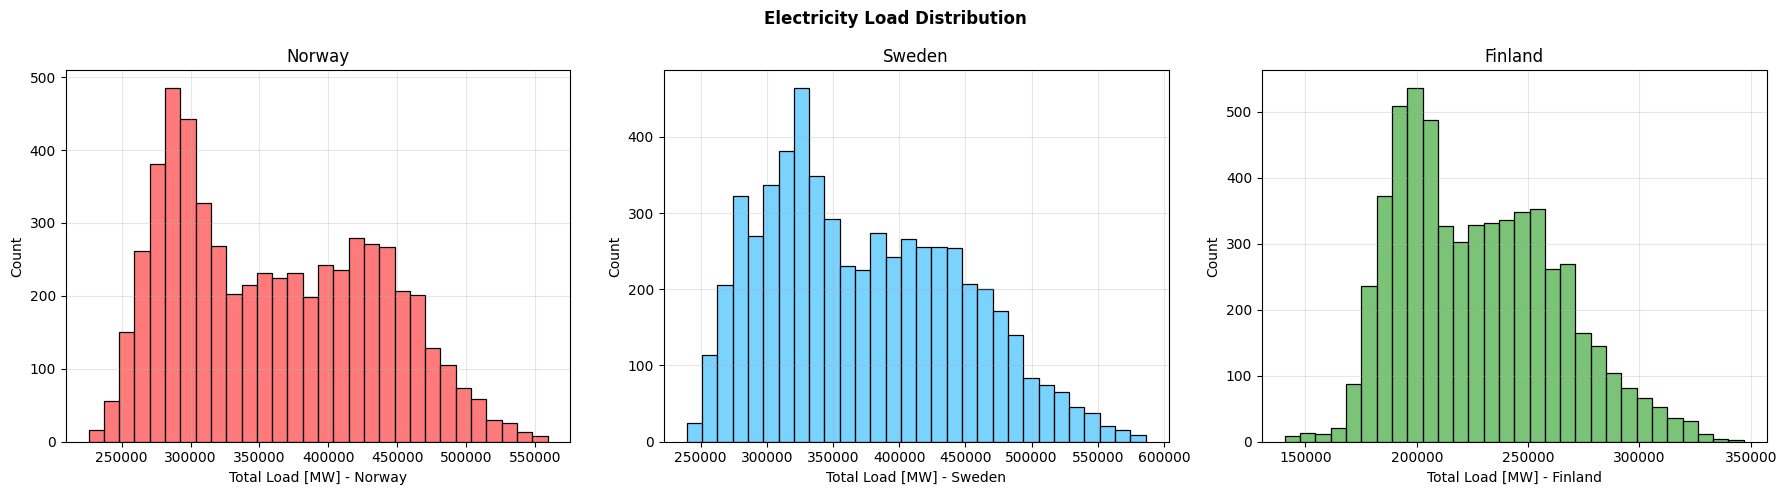

In [7]:
plot_load_distributions(df)

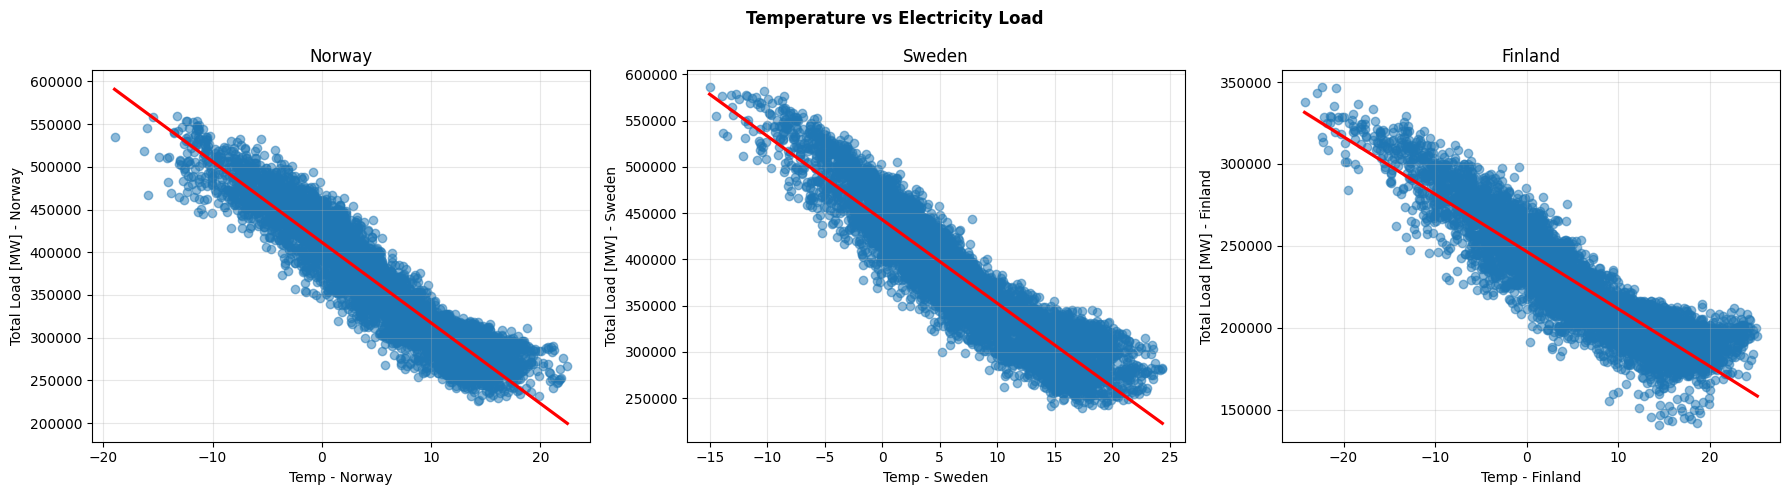

In [8]:
plot_temp_vs_load(df)

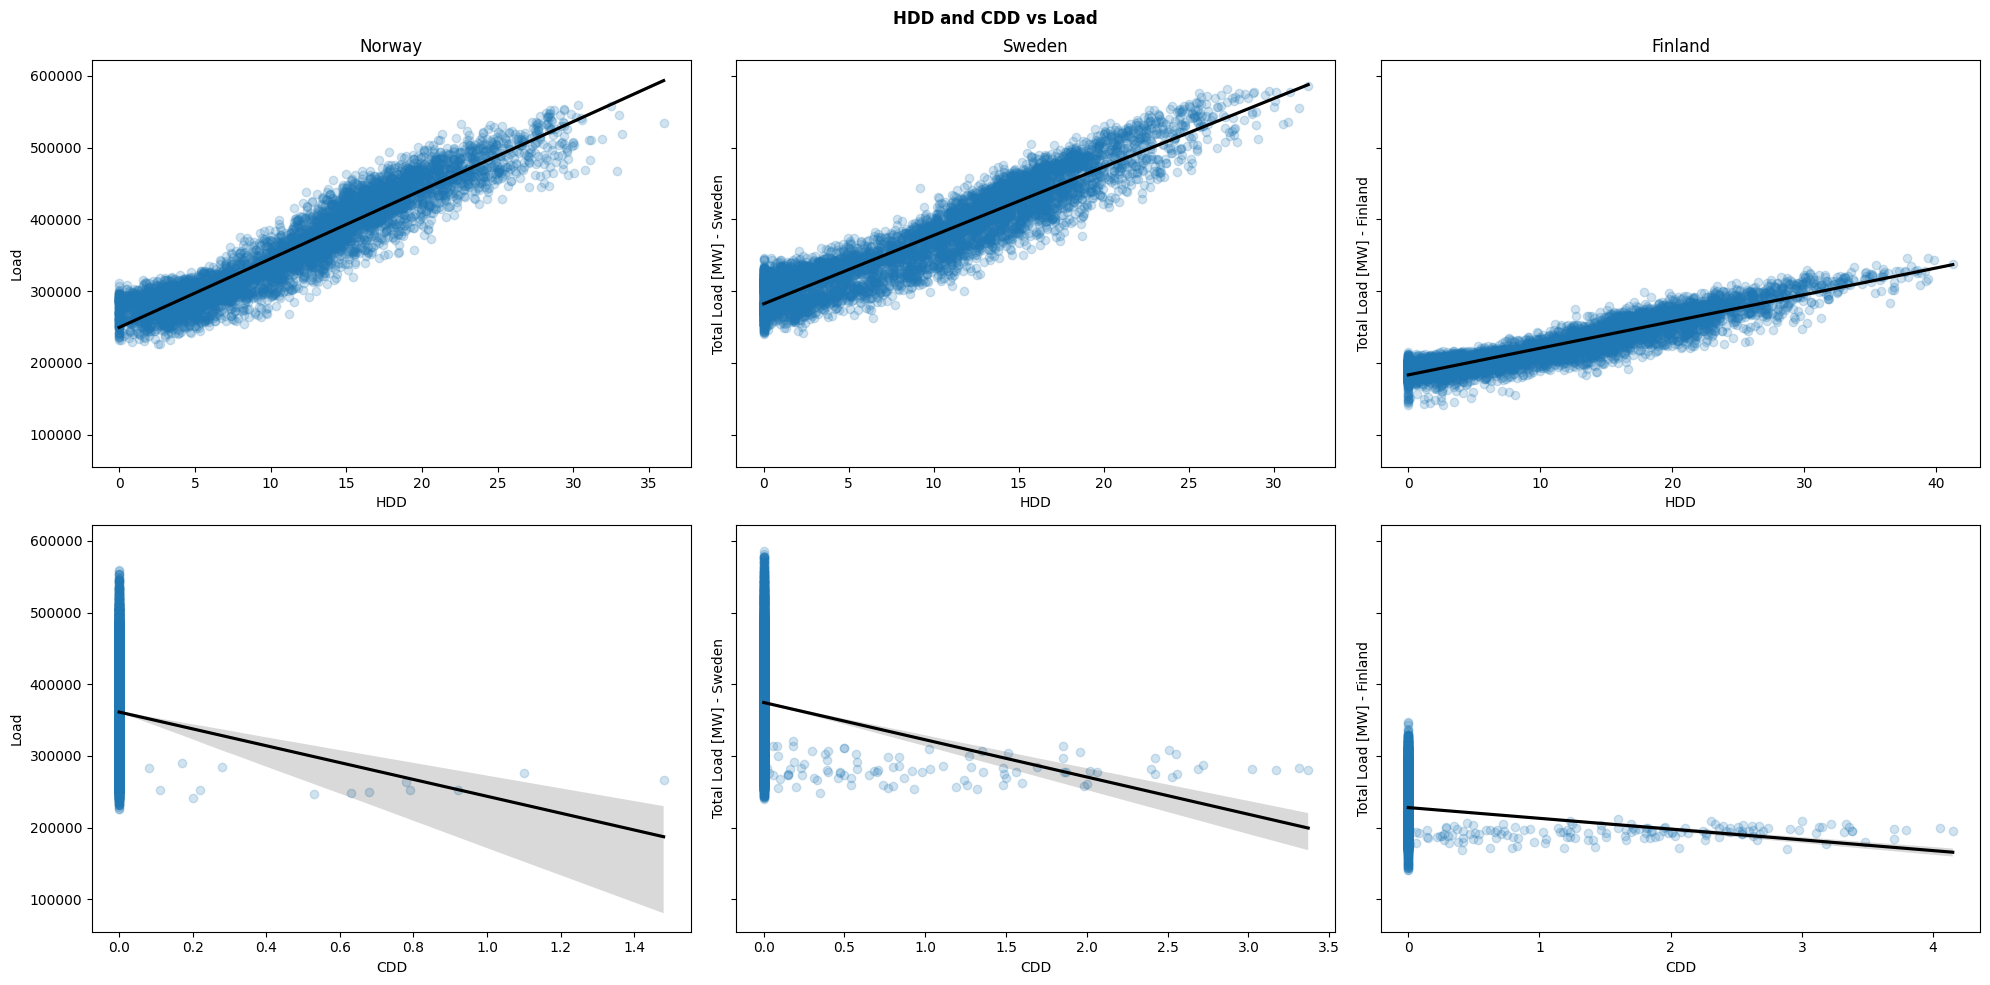

In [9]:
plot_hdd_cdd_relationships(df)